# Run pipeline: Tiny images / Bag-of-SIFT / NN / SVM
此 Notebook 用于按步骤运行作业流水线并保存部分示例输出（混淆矩阵、示例图片）。
如果时间或资源有限，可按单元逐段运行。

In [1]:
%matplotlib inline
import os
import os.path as osp
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from PIL import Image, ImageDraw, ImageFont

# 导入你实现的函数
from student_code_12311805 import get_tiny_images, build_vocabulary, get_bags_of_sifts, nearest_neighbor_classify, svm_classify
from utils import load_image, get_image_paths

OUTDIR = 'outputs'
os.makedirs(OUTDIR, exist_ok=True)

# 参数（可修改）
categories = ['Kitchen','Store','Bedroom','LivingRoom','Office','Industrial','Suburb',
              'InsideCity','TallBuilding','Street','Highway','OpenCountry','Coast',
              'Mountain','Forest']
num_train_per_cat = 100
vocab_filename = 'vocab.pkl'
vocab_size = 200

data_path = osp.join('..','data')
train_image_paths, test_image_paths, train_labels, test_labels = get_image_paths(data_path, categories, num_train_per_cat)
print('Loaded', len(train_image_paths), 'train and', len(test_image_paths), 'test images')

Loaded 1500 train and 1500 test images


Computing tiny image features...
tiny shapes: (1500, 256) (1500, 256)
Running NN on tiny images...
Tiny NN mean diagonal = 0.2286666666666644


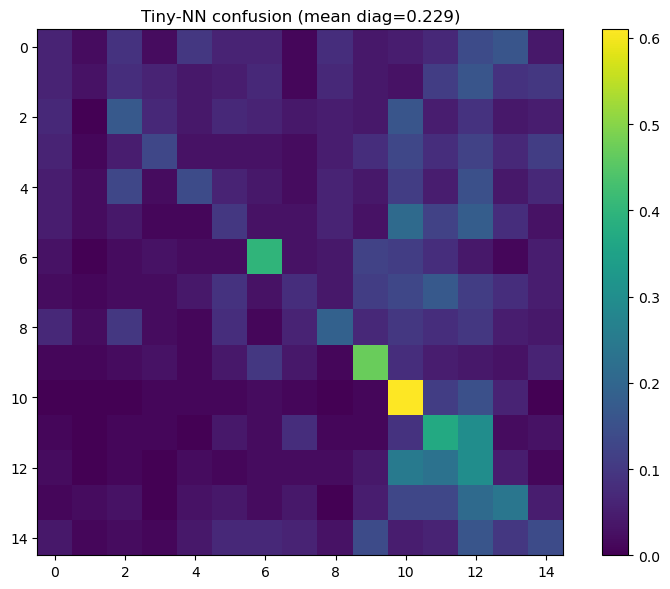

In [2]:
# --- Tiny images + NN (快速) ---
print('Computing tiny image features...')
train_tiny = get_tiny_images(train_image_paths)
test_tiny = get_tiny_images(test_image_paths)
print('tiny shapes:', train_tiny.shape, test_tiny.shape)

print('Running NN on tiny images...')
preds_tiny_nn = nearest_neighbor_classify(train_tiny, train_labels, test_tiny)
# 构建并显示混淆矩阵（按行归一化）
cm_tiny = confusion_matrix([categories.index(l) for l in test_labels], [categories.index(p) for p in preds_tiny_nn], labels=list(range(len(categories))))
cm_tiny_norm = (cm_tiny.astype(float) / (cm_tiny.sum(axis=1)[:, None] + 1e-12))
acc_tiny = np.mean(np.diag(cm_tiny_norm))
print('Tiny NN mean diagonal =', acc_tiny)
plt.figure(figsize=(8,6))
plt.imshow(cm_tiny_norm, cmap='viridis')
plt.title(f'Tiny-NN confusion (mean diag={acc_tiny:.3f})')
plt.colorbar()
plt.tight_layout()
plt.savefig(osp.join(OUTDIR,'confusion_tiny_nn.png'))
plt.show()

Loading existing vocab
Computing bag-of-sift features...
bags shapes: (1500, 200) (1500, 200)
Running NN on bag-of-sift (chi2) ...
Bag-NN mean diagonal = 0.5119999999999949


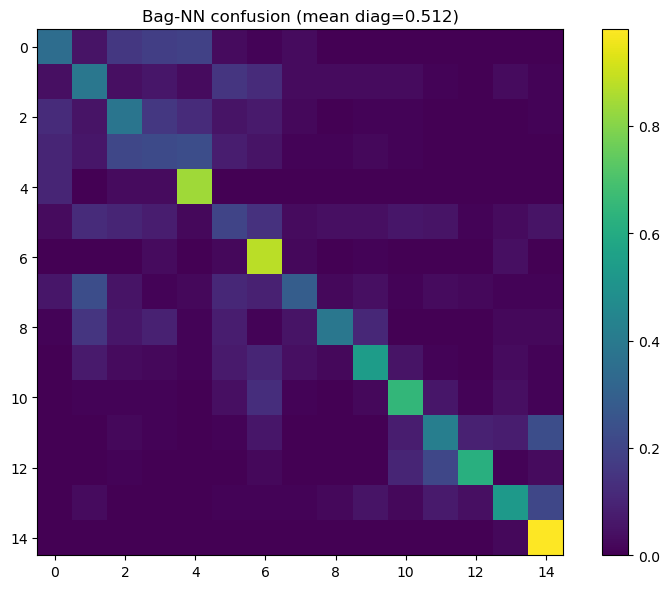

In [3]:
# --- Build / Load Vocab and compute Bag-of-SIFT (可能耗时) ---
if not osp.isfile(vocab_filename):
    print('Building visual vocabulary (this may take several minutes)')
    vocab = build_vocabulary(train_image_paths, vocab_size)
    with open(vocab_filename,'wb') as f:
        pickle.dump(vocab, f)
    print('Saved', vocab_filename)
else:
    print('Loading existing vocab')
    with open(vocab_filename,'rb') as f:
        vocab = pickle.load(f)

print('Computing bag-of-sift features...')
train_bags = get_bags_of_sifts(train_image_paths, vocab_filename)
test_bags = get_bags_of_sifts(test_image_paths, vocab_filename)
print('bags shapes:', train_bags.shape, test_bags.shape)

print('Running NN on bag-of-sift (chi2) ...')
preds_bag_nn = nearest_neighbor_classify(train_bags, train_labels, test_bags, metric='chi2')
cm_bag_nn = confusion_matrix([categories.index(l) for l in test_labels], [categories.index(p) for p in preds_bag_nn], labels=list(range(len(categories))))
cm_bag_nn_norm = (cm_bag_nn.astype(float) / (cm_bag_nn.sum(axis=1)[:, None] + 1e-12))
acc_bag_nn = np.mean(np.diag(cm_bag_nn_norm))
print('Bag-NN mean diagonal =', acc_bag_nn)
plt.figure(figsize=(8,6))
plt.imshow(cm_bag_nn_norm, cmap='viridis')
plt.title(f'Bag-NN confusion (mean diag={acc_bag_nn:.3f})')
plt.colorbar()
plt.tight_layout()
plt.savefig(osp.join(OUTDIR,'confusion_bag_nn.png'))
plt.show()

Running SVM on bag-of-sift (may take minutes)


/data2/cse12311805/miniconda/envs/assignment3/lib/python3.8/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/data2/cse12311805/miniconda/envs/assignment3/lib/python3.8/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/data2/cse12311805/miniconda/envs/assignment3/lib/python3.8/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/data2/cse12311805/miniconda/envs/assignment3/lib/python3.8/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/data2/cse12311805/miniconda/envs/assignment3/lib/python3.8/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  

Bag-SVM mean diagonal = 0.44933333333332887


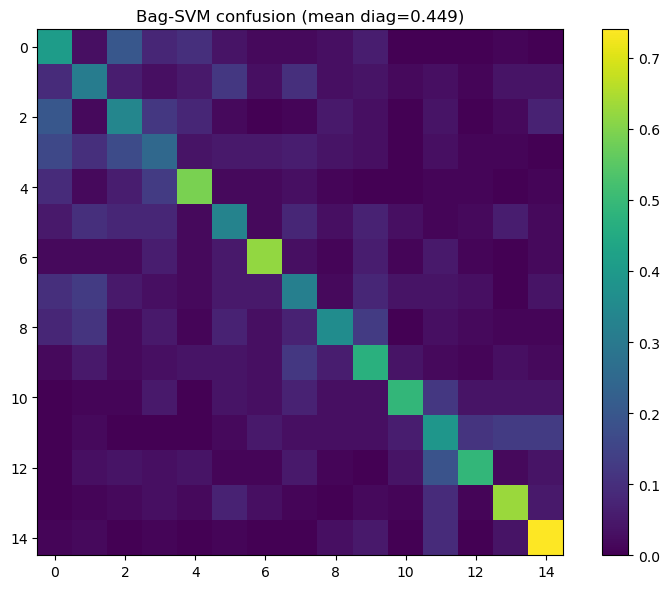

In [4]:
# --- SVM on bag-of-sift (训练多个 one-vs-all SVM) ---
print('Running SVM on bag-of-sift (may take minutes)')
preds_bag_svm = svm_classify(train_bags, train_labels, test_bags)
cm_bag_svm = confusion_matrix([categories.index(l) for l in test_labels], [categories.index(p) for p in preds_bag_svm], labels=list(range(len(categories))))
cm_bag_svm_norm = (cm_bag_svm.astype(float) / (cm_bag_svm.sum(axis=1)[:, None] + 1e-12))
acc_bag_svm = np.mean(np.diag(cm_bag_svm_norm))
print('Bag-SVM mean diagonal =', acc_bag_svm)
plt.figure(figsize=(8,6))
plt.imshow(cm_bag_svm_norm, cmap='viridis')
plt.title(f'Bag-SVM confusion (mean diag={acc_bag_svm:.3f})')
plt.colorbar()
plt.tight_layout()
plt.savefig(osp.join(OUTDIR,'confusion_bag_svm.png'))
plt.show()

In [5]:
# --- 保存若干示例预测图像（前 12 张测试图）---
EXAMPLES = 12
os.makedirs(osp.join(OUTDIR,'examples'), exist_ok=True)
for i, img_path in enumerate(test_image_paths[:EXAMPLES]):
    img = Image.open(img_path).convert('RGB')
    w,h = img.size
    maxw = 300
    if w>maxw:
        img = img.resize((maxw, int(h*maxw/w)))
    draw = ImageDraw.Draw(img)
    true = test_labels[i]
    nn_pred = preds_bag_nn[i]
    svm_pred = preds_bag_svm[i]
    text = f'True: {true}\nNN: {nn_pred}\nSVM: {svm_pred}'
    try:
        font = ImageFont.load_default()
    except Exception:
        font = None
    draw.text((5,5), text, fill=(255,0,0), font=font)
    img.save(osp.join(OUTDIR,'examples', f'example_{i}_{true}.jpg'))

print('Saved outputs to', OUTDIR)

Saved outputs to outputs


**提示与评分建议**:
- 保存并展示混淆矩阵图片（`outputs/confusion_*.png`）和示例预测图（`outputs/examples/*.jpg`）。这通常是评分时要看的内容。
- 要拿满分：提供三种组合的结果（tiny+NN, bag+NN, bag+SVM），显示每种的混淆矩阵与若干示例图；在报告中解释错误模式与改进思路；记录你使用的参数（vocab_size, SVM C, dsift step 等）。
- GPU: 本 notebook 使用纯 CPU 的 sklearn + cyvlfeat（若系统已配置 GPU 加速并使用相应库可改用），默认不会自动使用 GPU。